### Libraries

In [1]:
import numpy as np, scipy.linalg as sl, matplotlib.pyplot as plt
from pyscf import gto, dft
from pyscf.dft import numint
from pyscf.data import nist            # the physical constants that PySCF itself uses
HARTREE = nist.HARTREE2EV              # eV per hartree
BOHR    = nist.BOHR                    # angstrom per bohr
DEBYE   = nist.AU2DEBYE / nist.BOHR    # debye per (e * angstrom)

### Part 1

In [8]:
atom = gto.M(atom='H 0 0 0', basis='cc-pv5z', spin=1)   # 'H 0 0 0' defines a hydrogen atom at the origin
T = atom.intor('int1e_kin')     # kinetic energy matrix
V = atom.intor('int1e_nuc')     # electron-nucleus attraction matrix
S = atom.intor('int1e_ovlp')    # overlap matrix

eps, C = sl.eigh(T + V, S)
c1s = C[:, 0]
eps[:3]

c1s @ S @ c1s


np.float64(0.9999999999999989)

In [24]:
eps[:3]

array([-0.49999454, -0.07287335,  0.06814967])

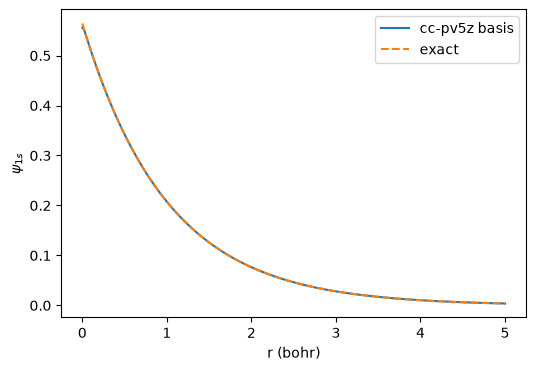

In [10]:
r = np.linspace(0, 5, 200)
pts = np.column_stack([0 * r, 0 * r, r])          # (x, y, z) in bohr
psi = numint.eval_ao(atom, pts) @ c1s             # the basis-set 1s orbital
if psi[0] < 0:                                    # the sign of an eigenvector is arbitrary
    psi = -psi

psi_exact = np.exp(-r) / np.sqrt(np.pi)           # the exact hydrogen 1s orbital

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(r, psi, label='cc-pv5z basis')
ax.plot(r, psi_exact, '--', label='exact')
ax.set_xlabel('r (bohr)')
ax.set_ylabel(r'$\psi_{1s}$')
ax.legend()
plt.show()

In [27]:
def lcao(R):
    molH2 = gto.M(atom=f'H 0 0 0; H 0 0 {R}', basis='cc-pv5z', charge=1, spin=1)
    Tm, Vm, Sm = molH2.intor('int1e_kin'), molH2.intor('int1e_nuc'), molH2.intor('int1e_ovlp')
    n = molH2.nao; nA = n // 2
    cA = np.zeros(n); cA[:nA] = c1s           # the 1s orbital on proton A
    cB = np.zeros(n); cB[nA:] = c1s           # the 1s orbital on proton B
    molA = gto.M(atom=f'H 0 0 0; ghost-H 0 0 {R}', basis='cc-pv5z', spin=1)
    molB = gto.M(atom=f'ghost-H 0 0 0; H 0 0 {R}', basis='cc-pv5z', spin=1)
    VA, VB = molA.intor('int1e_nuc'), molB.intor('int1e_nuc')

    eps0 = cA @ (Tm + VA) @ cA
    Vx   = cA @ VB @ cA
    t    = -(cA @ (Tm + Vm) @ cB)
    SAB  = cA @ Sm @ cB
    
    H2 = np.array([[eps0 + Vx, -t], [-t, eps0 + Vx]])
    S2 = np.array([[1.0, SAB], [SAB, 1.0]])
    H2 = H2 + molH2.energy_nuc() * S2          # the proton-proton repulsion
    return H2, S2, molH2, eps0, Vx, t, SAB, VA, VB, Vm



In [25]:
H2, S2, molH2, eps0, Vx, t, SAB, VA, VB, Vm = lcao(1.3)
print(H2)
print(S2)
print(eps0)
print(Vx)
print(t)
print(SAB)

print("Va + Vb = Vm?")
print(np.allclose(VA + VB, Vm))

[[-0.48965754 -0.33987547]
 [-0.33987547 -0.48965754]]
[[1.         0.46874313]
 [0.46874313 1.        ]]
-0.49999453515890235
-0.3967224001131689
0.5306817678660136
0.46874313031045467
Va + Vb = Vm?
True


In [26]:
H2, S2, molH2, eps0, Vx, t, SAB, VA, VB, Vm = lcao(300)
print(H2)
print(S2)
print(eps0)
print(Vx)
print(t)
print(SAB)

print("Va + Vb = Vm?")
print(np.allclose(VA + VB, Vm))

[[-0.49999454  0.        ]
 [ 0.         -0.49999454]]
[[1. 0.]
 [0. 1.]]
-0.49999453515890235
-0.0017639240363999979
-0.0
0.0
Va + Vb = Vm?
True


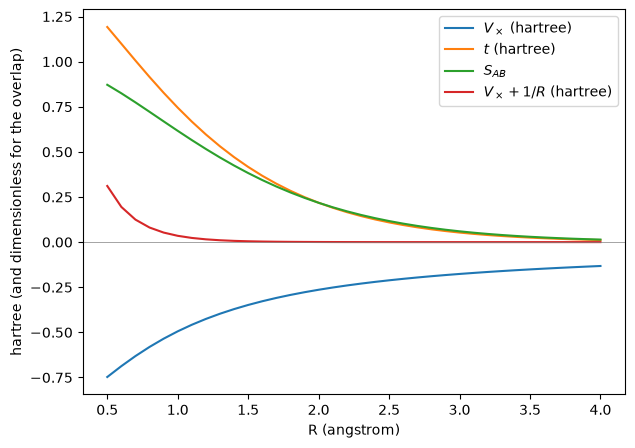

In [29]:
Rs = np.arange(0.5, 4.01, 0.1)                   # bond lengths in angstrom

Vx_list, t_list, SAB_list, sum_list = [], [], [], []

for R in Rs:
    H2, S2, molH2, eps0, Vx, t, SAB, VA, VB, Vm = lcao(R)
    Vx_list.append(Vx)
    t_list.append(t)
    SAB_list.append(SAB)
    sum_list.append(Vx + molH2.energy_nuc())     # 1/R in hartree

Vx_arr   = np.array(Vx_list)
t_arr    = np.array(t_list)
SAB_arr  = np.array(SAB_list)
sum_arr  = np.array(sum_list)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(Rs, Vx_arr,  label=r'$V_\times$ (hartree)')
ax.plot(Rs, t_arr,   label=r'$t$ (hartree)')
ax.plot(Rs, SAB_arr, label=r'$S_{AB}$')
ax.plot(Rs, sum_arr, label=r'$V_\times + 1/R$ (hartree)')
ax.axhline(0, color='gray', lw=0.5)
ax.set_xlabel('R (angstrom)')
ax.set_ylabel('hartree (and dimensionless for the overlap)')
ax.legend()
plt.show()

In [30]:
for R in [1.3, 2.0, 3.0]:                        # angstrom
    out = lcao(R)
    SAB_basis = out[6]
    R_bohr = R / BOHR                            # convert angstrom to bohr
    SAB_exact = np.exp(-R_bohr) * (1 + R_bohr + R_bohr**2 / 3)
    print(f"R = {R:.1f} A  ({R_bohr:.3f} bohr):  basis {SAB_basis:.4f}   closed form {SAB_exact:.4f}")

R = 1.3 A  (2.457 bohr):  basis 0.4687   closed form 0.4688
R = 2.0 A  (3.779 bohr):  basis 0.2178   closed form 0.2179
R = 3.0 A  (5.669 bohr):  basis 0.0599   closed form 0.0600


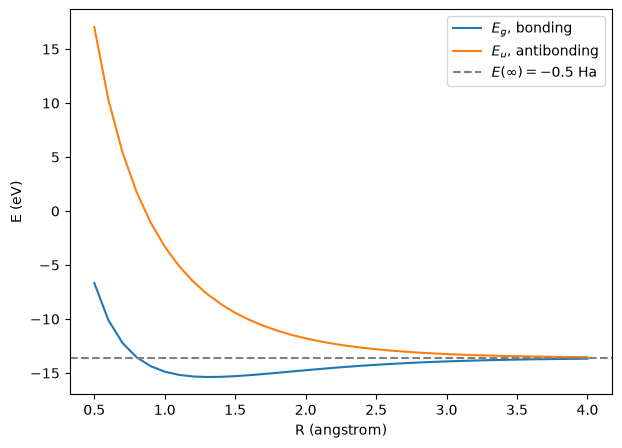

In [31]:
Rs = np.arange(0.5, 4.01, 0.1)                   # angstrom

Eg_list, Eu_list = [], []
for R in Rs:
    H2, S2, *_ = lcao(R)
    E, c = sl.eigh(H2, S2)
    Eg_list.append(E[0])                         # bonding, lower eigenvalue
    Eu_list.append(E[1])                         # antibonding, upper eigenvalue

Eg = np.array(Eg_list) * HARTREE                 # eV
Eu = np.array(Eu_list) * HARTREE                 # eV

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(Rs, Eg, label=r'$E_g$, bonding')
ax.plot(Rs, Eu, label=r'$E_u$, antibonding')
ax.axhline(-0.5 * HARTREE, color='gray', ls='--', label=r'$E(\infty) = -0.5$ Ha')
ax.set_xlabel('R (angstrom)')
ax.set_ylabel('E (eV)')
ax.legend()
plt.show()

In [32]:
i = np.argmin(Eg)                                 # index of the lowest point
print(f"R0 = {Rs[i]:.2f} A")
print(f"Eg(R0) = {Eg[i] / HARTREE:.4f} Ha  =  {Eg[i]:.3f} eV")
print(f"De = {(-0.5 - Eg[i] / HARTREE) * HARTREE:.2f} eV")

R0 = 1.30 A
Eg(R0) = -0.5648 Ha  =  -15.369 eV
De = 1.76 eV


In [33]:
H2, S2, *_ = lcao(1.3)
E, c = sl.eigh(H2, S2)

print("bonding eigenvector    c[:, 0] =", c[:, 0])
print("antibonding eigenvector c[:, 1] =", c[:, 1])
print(f"1/sqrt(2) = {1 / np.sqrt(2):.4f}")
print(f"normalisation check, c[:,0] @ S2 @ c[:,0] = {c[:, 0] @ S2 @ c[:, 0]:.6f}")

bonding eigenvector    c[:, 0] = [-0.58346133 -0.58346133]
antibonding eigenvector c[:, 1] = [ 0.97013623 -0.97013623]
1/sqrt(2) = 0.7071
normalisation check, c[:,0] @ S2 @ c[:,0] = 1.000000


In [34]:
print(c[:, 0] @ c[:, 0])            # plain dot product
print(c[:, 0] @ S2 @ c[:, 0])       # with the overlap matrix

0.6808542483454036
1.0


check 1: 1.000000
check 2: 1.000000


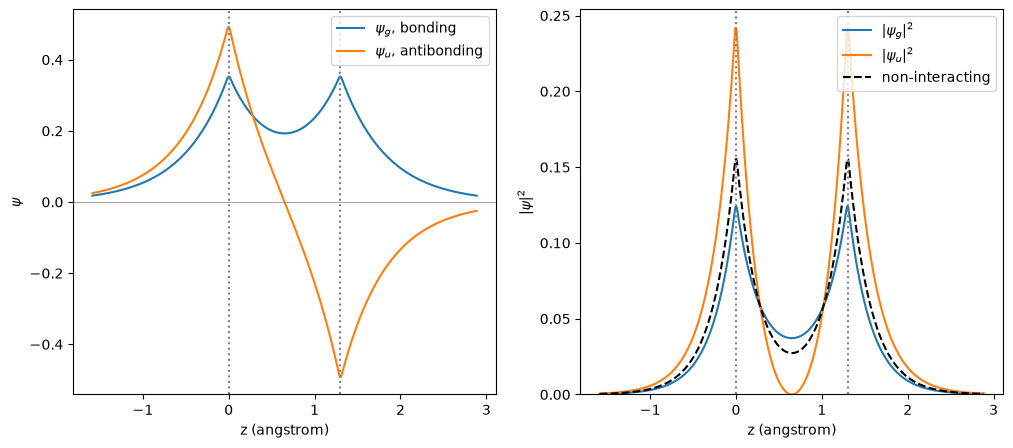

In [38]:
R0 = 1.3                                              # angstrom, from section 1.3

H2, S2, molH2, *_ = lcao(R0)
E, c = sl.eigh(H2, S2)

n = molH2.nao; nA = n // 2                            # rebuild cA, cB and Sm at R0
cA = np.zeros(n); cA[:nA] = c1s
cB = np.zeros(n); cB[nA:] = c1s
Sm = molH2.intor('int1e_ovlp')

z = np.linspace(-3, 3 + R0 / BOHR, 400)               # bohr, along the bond axis
pts = np.column_stack([0 * z, 0 * z, z])
ao = numint.eval_ao(molH2, pts)
Cb = np.column_stack([cA, cB])

psi_A, psi_B = ao @ cA, ao @ cB
psi_g = ao @ (Cb @ c[:, 0])
psi_u = ao @ (Cb @ c[:, 1])

if psi_g[len(z) // 2] < 0:                            # fix the arbitrary sign
    psi_g = -psi_g

print(f"check 1: {c[:, 0] @ S2 @ c[:, 0]:.6f}")
print(f"check 2: {(Cb @ c[:, 0]) @ Sm @ (Cb @ c[:, 0]):.6f}")

z_ang = z * BOHR                                      # convert bohr to angstrom for the axes

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(z_ang, psi_g, label=r'$\psi_g$, bonding')
ax1.plot(z_ang, psi_u, label=r'$\psi_u$, antibonding')
ax1.axvline(0, color='gray', ls=':')                  # proton A
ax1.axvline(R0, color='gray', ls=':')                 # proton B
ax1.axhline(0, color='gray', lw=0.5)
ax1.set_xlabel('z (angstrom)'); ax1.set_ylabel(r'$\psi$')
ax1.legend()

ax2.plot(z_ang, psi_g**2, label=r'$|\psi_g|^2$')
ax2.plot(z_ang, psi_u**2, label=r'$|\psi_u|^2$')
ax2.plot(z_ang, 0.5 * (psi_A**2 + psi_B**2), 'k--', label='non-interacting')
ax2.axvline(0, color='gray', ls=':')
ax2.axvline(R0, color='gray', ls=':')
ax2.set_ylim(0, None)                                 # so the node touches the axis
ax2.set_xlabel('z (angstrom)'); ax2.set_ylabel(r'$|\psi|^2$')
ax2.legend()

plt.show()

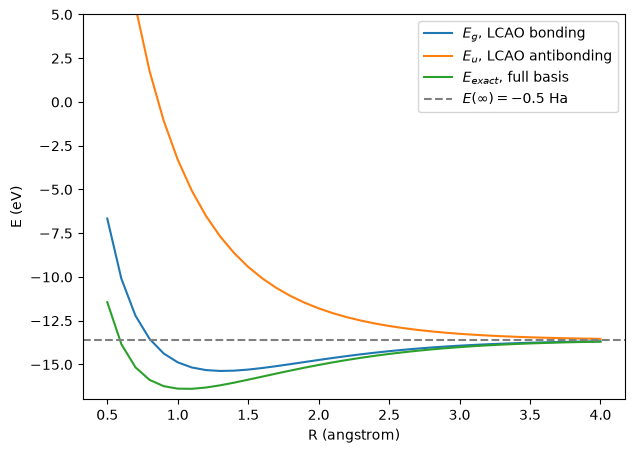

full basis: R0 = 1.10 A
full basis: E(R0) = -0.6023 Ha
full basis: De = 2.78 eV


In [40]:
Rs = np.arange(0.5, 4.01, 0.1)                        # angstrom

Eg_list, Eu_list, Ex_list = [], [], []
for R in Rs:
    H2, S2, molH2, *_ = lcao(R)
    E, c = sl.eigh(H2, S2)
    Eg_list.append(E[0])
    Eu_list.append(E[1])

    Tm = molH2.intor('int1e_kin')                     # the molecule's matrices
    Vm = molH2.intor('int1e_nuc')
    Sm = molH2.intor('int1e_ovlp')
    e, C = sl.eigh(Tm + Vm, Sm)                       # all 110 basis functions
    Ex_list.append(e[0] + molH2.energy_nuc())

Eg = np.array(Eg_list) * HARTREE                      # eV
Eu = np.array(Eu_list) * HARTREE
Ex = np.array(Ex_list) * HARTREE

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(Rs, Eg, label=r'$E_g$, LCAO bonding')
ax.plot(Rs, Eu, label=r'$E_u$, LCAO antibonding')
ax.plot(Rs, Ex, label=r'$E_{exact}$, full basis')
ax.axhline(-0.5 * HARTREE, color='gray', ls='--', label=r'$E(\infty) = -0.5$ Ha')
ax.set_xlabel('R (angstrom)'); ax.set_ylabel('E (eV)')
ax.set_ylim(-17, 5)
ax.legend()
plt.show()

i = np.argmin(Ex)
print(f"full basis: R0 = {Rs[i]:.2f} A")
print(f"full basis: E(R0) = {Ex[i] / HARTREE:.4f} Ha")
print(f"full basis: De = {(-0.5 - Ex[i] / HARTREE) * HARTREE:.2f} eV")


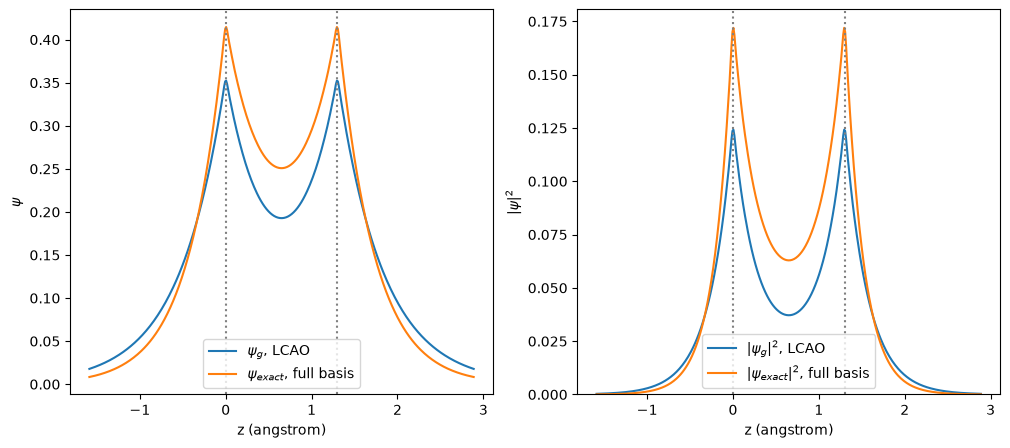

at the midpoint:  LCAO density 0.0372   full basis 0.0629


In [41]:
R0 = 1.3                                              # the LCAO optimum, angstrom

H2, S2, molH2, *_ = lcao(R0)
E, c = sl.eigh(H2, S2)

n = molH2.nao; nA = n // 2
cA = np.zeros(n); cA[:nA] = c1s
cB = np.zeros(n); cB[nA:] = c1s
Cb = np.column_stack([cA, cB])

Tm = molH2.intor('int1e_kin')
Vm = molH2.intor('int1e_nuc')
Sm = molH2.intor('int1e_ovlp')
e, C = sl.eigh(Tm + Vm, Sm)                           # full 110-function solution

z = np.linspace(-3, 3 + R0 / BOHR, 400)               # bohr
pts = np.column_stack([0 * z, 0 * z, z])
ao = numint.eval_ao(molH2, pts)

psi_g     = ao @ (Cb @ c[:, 0])                       # LCAO bonding state
psi_exact = ao @ C[:, 0]                              # full basis ground state

mid = np.argmin(np.abs(z - 0.5 * R0 / BOHR))          # index of the midpoint
if psi_g[mid] < 0:
    psi_g = -psi_g
if psi_exact[mid] < 0:
    psi_exact = -psi_exact

z_ang = z * BOHR

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(z_ang, psi_g,     label=r'$\psi_g$, LCAO')
ax1.plot(z_ang, psi_exact, label=r'$\psi_{exact}$, full basis')
ax1.axvline(0, color='gray', ls=':'); ax1.axvline(R0, color='gray', ls=':')
ax1.set_xlabel('z (angstrom)'); ax1.set_ylabel(r'$\psi$'); ax1.legend()

ax2.plot(z_ang, psi_g**2,     label=r'$|\psi_g|^2$, LCAO')
ax2.plot(z_ang, psi_exact**2, label=r'$|\psi_{exact}|^2$, full basis')
ax2.axvline(0, color='gray', ls=':'); ax2.axvline(R0, color='gray', ls=':')
ax2.set_ylim(0, None)
ax2.set_xlabel('z (angstrom)'); ax2.set_ylabel(r'$|\psi|^2$'); ax2.legend()

plt.show()

print(f"at the midpoint:  LCAO density {psi_g[mid]**2:.4f}   full basis {psi_exact[mid]**2:.4f}")

### Part 2

In [49]:
def run_molecule(A, B, R):
    mol = gto.M(atom=f'{A} 0 0 0; {B} 0 0 {R}', basis='def2-tzvp', verbose=0)
    mf = dft.RKS(mol); mf.xc = 'b3lyp'; mf.kernel()
    return mf

In [50]:
def run_atom(A):
    mol = gto.M(atom=f'{A} 0 0 0', basis='def2-tzvp', spin=1, verbose=0)
    mf = dft.UKS(mol); mf.xc = 'b3lyp'; mf.kernel()
    return mf.e_tot

In [51]:
E_atom = {}                                           # a dictionary: element name -> energy
for A in ['H', 'Li', 'Na', 'F', 'Cl']:
    E_atom[A] = run_atom(A)

print(f"{'atom':<6} {'E (hartree)':>16}")
for A, E in E_atom.items():
    print(f"{A:<6} {E:>16.6f}")

atom        E (hartree)
H             -0.502154
Li            -7.492798
Na          -162.291265
F            -99.770150
Cl          -460.166979


ClCl   R0 = 2.02 A   E(R0) = -920.421982 Ha
HCl    R0 = 1.28 A   E(R0) = -460.835098 Ha
NaCl   R0 = 2.36 A   E(R0) = -622.605045 Ha
FF     R0 = 1.40 A   E(R0) = -199.599537 Ha
HF     R0 = 0.92 A   E(R0) = -100.490442 Ha
LiF    R0 = 1.56 A   E(R0) = -107.475698 Ha


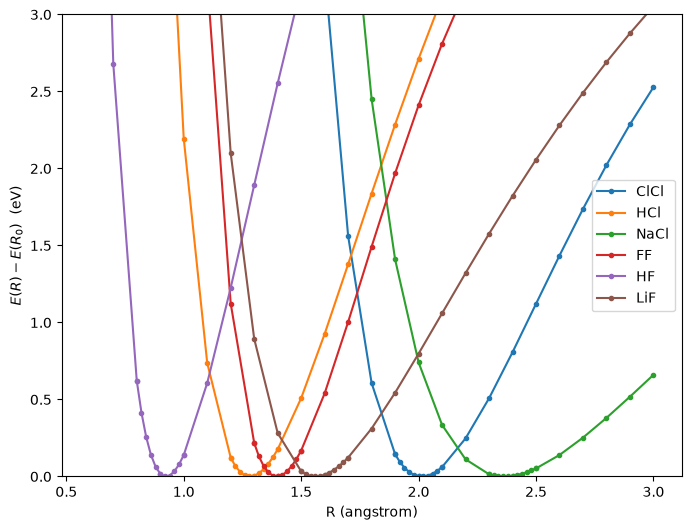

In [47]:
molecules = [('Cl', 'Cl'), ('H', 'Cl'), ('Na', 'Cl'),
             ('F', 'F'),   ('H', 'F'),  ('Li', 'F')]

results = {}                                          # label -> (R values, E values, R0, E0)

for A, B in molecules:
    label = f"{A}{B}"

    R_coarse = np.arange(0.6, 3.001, 0.1)             # coarse grid, angstrom
    E_coarse = np.array([run_molecule(A, B, R).e_tot for R in R_coarse])
    R_best = R_coarse[np.argmin(E_coarse)]

    R_fine = np.arange(R_best - 0.1, R_best + 0.1001, 0.02)     # fine grid
    E_fine = np.array([run_molecule(A, B, R).e_tot for R in R_fine])

    R_all = np.concatenate([R_coarse, R_fine])        # both grids together
    E_all = np.concatenate([E_coarse, E_fine])
    order = np.argsort(R_all)                         # sort by distance for plotting
    R_all, E_all = R_all[order], E_all[order]

    i = np.argmin(E_all)
    results[label] = (R_all, E_all, R_all[i], E_all[i])
    print(f"{label:<6} R0 = {R_all[i]:.2f} A   E(R0) = {E_all[i]:.6f} Ha")

fig, ax = plt.subplots(figsize=(8, 6))
for label, (R_all, E_all, R0, E0) in results.items():
    ax.plot(R_all, (E_all - E0) * HARTREE, marker='.', label=label)
ax.set_ylim(0, 3)
ax.set_xlabel('R (angstrom)')
ax.set_ylabel(r'$E(R) - E(R_0)$  (eV)')
ax.legend()
plt.show() 

In [52]:
D0_exp = {'ClCl': 2.48, 'HCl': 4.43, 'NaCl': 4.23,
          'FF': 1.60, 'HF': 5.87, 'LiF': 5.91}        # eV, Appendix B

pairs = {'ClCl': ('Cl', 'Cl'), 'HCl': ('H', 'Cl'), 'NaCl': ('Na', 'Cl'),
         'FF': ('F', 'F'), 'HF': ('H', 'F'), 'LiF': ('Li', 'F')}

De = {}
print(f"{'molecule':<10} {'De (eV)':>9} {'D0 exp (eV)':>13} {'diff':>8}")
for label, (R_all, E_all, R0, E0) in results.items():
    A, B = pairs[label]
    De[label] = (E_atom[A] + E_atom[B] - E0) * HARTREE
    print(f"{label:<10} {De[label]:>9.2f} {D0_exp[label]:>13.2f} {De[label] - D0_exp[label]:>8.2f}")

molecule     De (eV)   D0 exp (eV)     diff
ClCl            2.40          2.48    -0.08
HCl             4.52          4.43     0.09
NaCl            3.99          4.23    -0.24
FF              1.61          1.60     0.01
HF              5.94          5.87     0.07
LiF             5.79          5.91    -0.12


In [53]:
mu_exp = {'ClCl': 0.0, 'HCl': 1.11, 'NaCl': 9.00,
          'FF': 0.0, 'HF': 1.83, 'LiF': 6.33}         # debye, Appendix B

charges = {}                                          # label -> (q_mulliken, mu_z, q_dipole)

print(f"{'molecule':<10} {'atom A':>7} {'q_Mull':>8} {'mu_z (D)':>10} {'mu exp (D)':>11} {'q_dip':>7}")
for label, (R_all, E_all, R0, E0) in results.items():
    A, B = pairs[label]
    mf = run_molecule(A, B, R0)                       # re-run the SCF at the minimum
    pop, q = mf.mulliken_pop(verbose=0)
    mu = mf.dip_moment(unit='Debye', verbose=0)

    q_mull = q[0]                                     # charge on the first atom
    mu_z = mu[2]                                      # the bond lies along z
    q_dip = abs(mu_z) / (DEBYE * R0)                  # dipole charge, in units of e

    charges[label] = (q_mull, mu_z, q_dip)
    print(f"{label:<10} {A:>7} {q_mull:>8.2f} {mu_z:>10.2f} {mu_exp[label]:>11.2f} {q_dip:>7.2f}")

molecule    atom A   q_Mull   mu_z (D)  mu exp (D)   q_dip
ClCl            Cl    -0.00       0.00        0.00    0.00
HCl              H     0.23      -1.24        1.11    0.20
NaCl            Na     0.65      -8.58        9.00    0.76
FF               F     0.00      -0.00        0.00    0.00
HF               H     0.40      -1.93        1.83    0.44
LiF             Li     0.75      -6.12        6.33    0.82


molecule     dchi   q_Mull   q_dip    diff
ClCl         0.00     0.00    0.00    0.00
HCl          0.96     0.23    0.20    0.03
NaCl         2.23     0.65    0.76   -0.11
FF           0.00     0.00    0.00   -0.00
HF           1.78     0.40    0.44   -0.04
LiF          3.00     0.75    0.82   -0.07


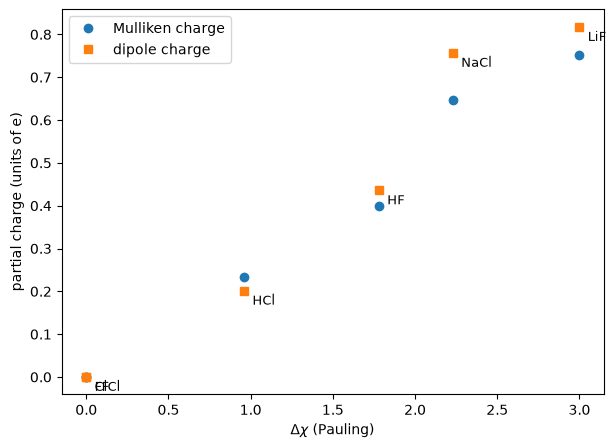

In [54]:
chi = {'H': 2.20, 'Li': 0.98, 'Na': 0.93, 'F': 3.98, 'Cl': 3.16}   # Pauling, Appendix B

print(f"{'molecule':<10} {'dchi':>6} {'q_Mull':>8} {'q_dip':>7} {'diff':>7}")
dchi_list, qm_list, qd_list, labels = [], [], [], []
for label, (q_mull, mu_z, q_dip) in charges.items():
    A, B = pairs[label]
    dchi = abs(chi[A] - chi[B])
    dchi_list.append(dchi); qm_list.append(abs(q_mull)); qd_list.append(q_dip)
    labels.append(label)
    print(f"{label:<10} {dchi:>6.2f} {abs(q_mull):>8.2f} {q_dip:>7.2f} {abs(q_mull) - q_dip:>7.2f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(dchi_list, qm_list, 'o', label='Mulliken charge')
ax.plot(dchi_list, qd_list, 's', label='dipole charge')
for x, y, lab in zip(dchi_list, qd_list, labels):
    ax.annotate(lab, (x, y), textcoords='offset points', xytext=(6, -10), fontsize=9)
ax.set_xlabel(r'$\Delta\chi$ (Pauling)')
ax.set_ylabel('partial charge (units of e)')
ax.legend()
plt.show()